In [100]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import cross_val_score
import pandas as pd
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt
import numpy as np

In [101]:
df = pd.read_csv("C://Users//Acer//OneDrive//Desktop//Datasets//random_chatgpt.csv")
df.sample(5)
x = df.drop(columns=['Salary'])
y = df['Salary']

In [102]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)
pca = PCA(n_components=1)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

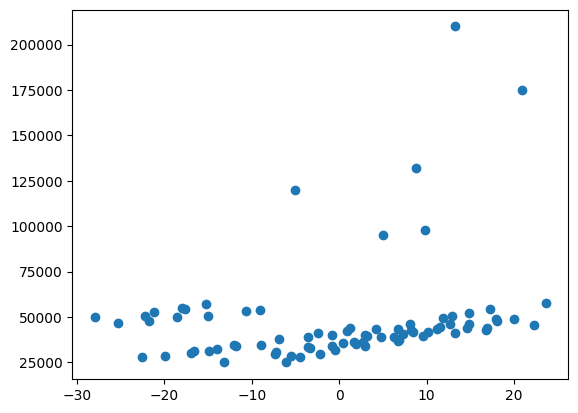

In [103]:
plt.scatter(x_train_pca,y_train)

dt has r2 score -0.7425589676070444
svr has r2 score -0.10635278065941763
lr has r2 score -0.44761642133929797


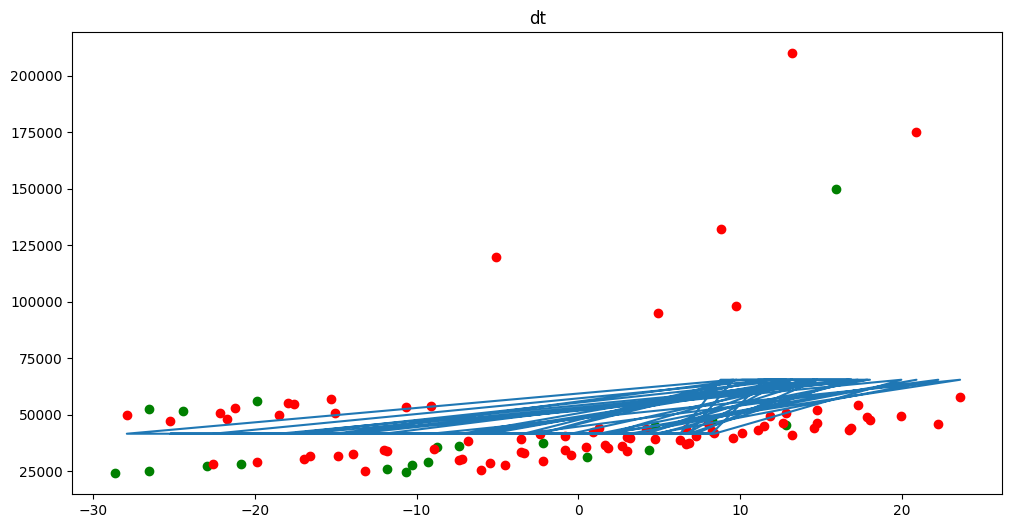

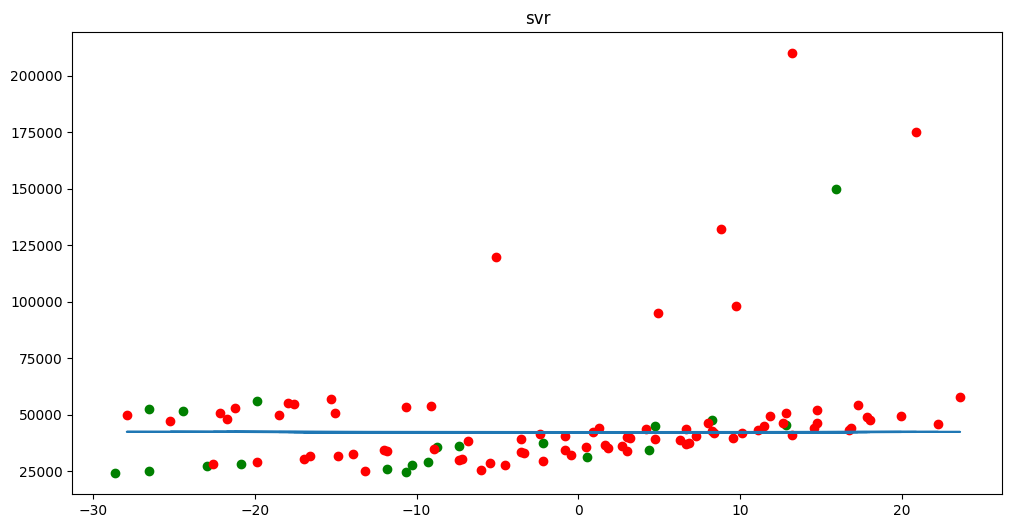

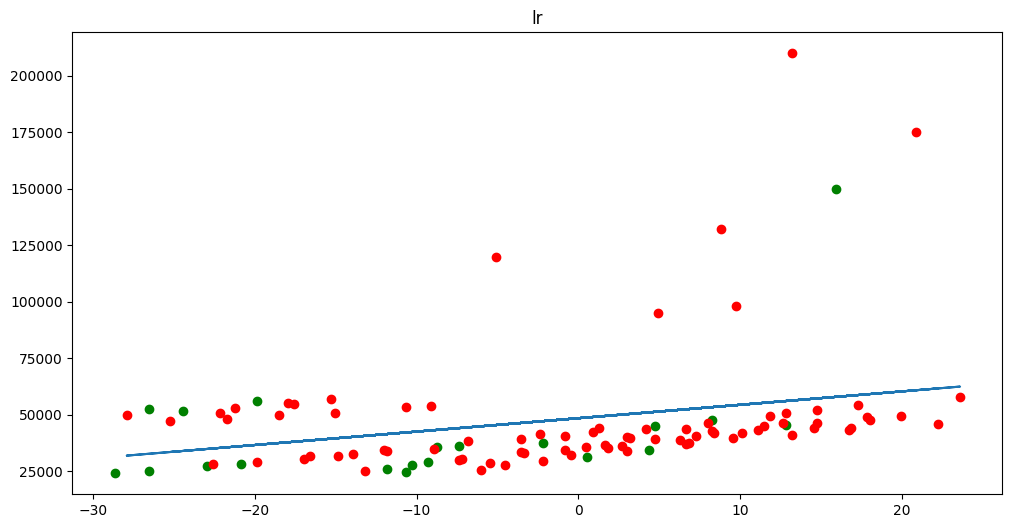

In [104]:
dt = DecisionTreeRegressor(max_depth=1)
svr = SVR(kernel='poly',degree=2)
lr = LinearRegression()
estimators = [('dt',dt),('svr',svr),('lr',lr)]

for estimator in estimators:
    estimator[1].fit(x_train_pca,y_train)
    cv = cross_val_score(estimator[1],x_train_pca,y_train,scoring='r2',cv=7)
    print(f"{estimator[0]} has r2 score {np.mean(cv)}")
    plt.figure(figsize=(12,6))
    plt.scatter(x_test_pca,y_test,c='green',label='test')
    plt.scatter(x_train_pca,y_train,c='red',label='train')
    plt.plot(x_train_pca,estimator[1].predict(x_train_pca))
    plt.title(f"{estimator[0]}")

 Votinf regressor has r2 score -0.177963927404741


Text(0.5, 1.0, 'VR')

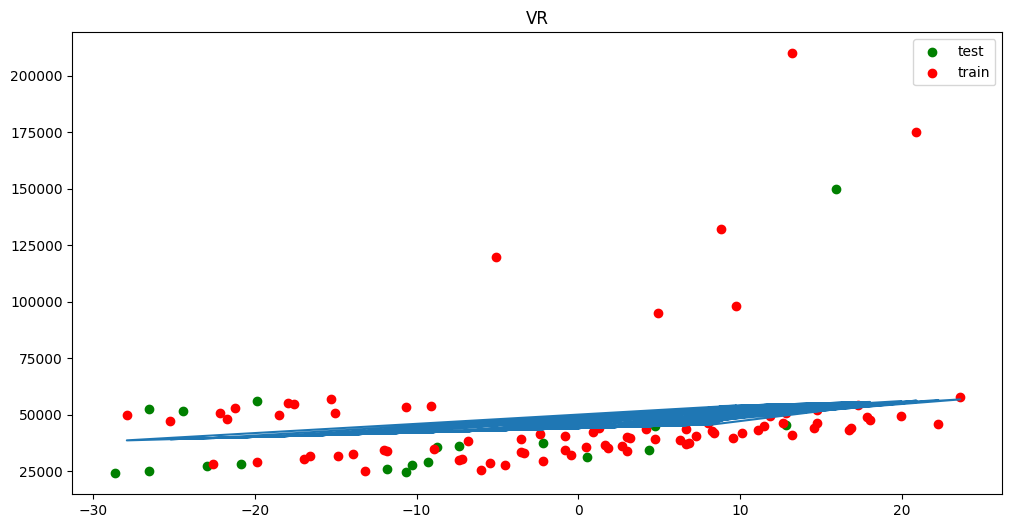

In [ ]:
vr = VotingRegressor(estimators=estimators)
vr.fit(x_train_pca,y_train)
cv = cross_val_score(vr,x_train_pca,y_train,scoring='r2',cv=7)
print(f" Voting regressor has r2 score {np.mean(cv)}")
plt.figure(figsize=(12,6))
plt.scatter(x_test_pca,y_test,c='green',label='test')
plt.scatter(x_train_pca,y_train,c='red',label='train')
plt.plot(x_train_pca,vr.predict(x_train_pca))
plt.legend()
plt.title("VR")

In [106]:
dt1 = DecisionTreeRegressor(max_depth=1)
dt2 = DecisionTreeRegressor(max_depth=3)
dt3 = DecisionTreeRegressor(max_depth=5)
dt4 = DecisionTreeRegressor(max_depth=10)

estimators_dt = [('dt1',dt1),('dt2',dt2),('dt3',dt3),('dt4',dt4)]
cv_scores = []
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            for a in range(1,4):
                voting = VotingRegressor(estimators=estimators_dt,weights=[i,j,k,a])
                voting.fit(x_train_pca,y_train)
                cv_dt = cross_val_score(voting,x_train_pca,y_train,scoring='r2',cv=7)
                print(f"[{i},{j},{k},{a}] r2 score = {np.mean(cv_dt)}")
                cv_scores.append(np.mean(cv_dt))

print(f"Highest r2 score {np.max(cv_scores)}")

[1,1,1,1] r2 score = -2.6711877875333414
[1,1,1,2] r2 score = -3.4534022480438535
[1,1,1,3] r2 score = -4.064249876847509
[1,1,2,1] r2 score = -3.1839216736767484
[1,1,2,2] r2 score = -3.7878636207526157
[1,1,2,3] r2 score = -4.275714828920831
[1,1,3,1] r2 score = -3.576982628059638
[1,1,3,2] r2 score = -4.055212653468063
[1,1,3,3] r2 score = -4.453458643665223
[1,2,1,1] r2 score = -2.22485494861593
[1,2,1,2] r2 score = -2.8458490614685297
[1,2,1,3] r2 score = -3.3808499280650404
[1,2,2,1] r2 score = -2.6467831635517043
[1,2,2,2] r2 score = -3.169028230406995
[1,2,2,3] r2 score = -3.619725944638676
[1,2,3,1] r2 score = -3.0053328487177042
[1,2,3,2] r2 score = -3.444195248341587
[1,2,3,3] r2 score = -3.8268835798198357
[1,3,1,1] r2 score = -1.9984069758294167
[1,3,1,2] r2 score = -2.4898976433517097
[1,3,1,3] r2 score = -2.9445188388040564
[1,3,2,1] r2 score = -2.3348827394571416
[1,3,2,2] r2 score = -2.775634133318552
[1,3,2,3] r2 score = -3.175972871558343
[1,3,3,1] r2 score = -2.6435

In [107]:
svr1 = SVR(kernel='poly',degree=1)
svr2 = SVR(kernel='poly',degree=2)
svr3 = SVR(kernel='poly',degree=3)
svr4 = SVR(kernel='poly',degree=4)

estimators_dt = [('svr1',svr1),('svr2',svr2),('svr3',svr3),('svr4',svr4)]
cv_scores = []
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            for a in range(1,4):
                voting = VotingRegressor(estimators=estimators_dt,weights=[i,j,k,a])
                voting.fit(x_train_pca,y_train)
                cv_dt = cross_val_score(voting,x_train_pca,y_train,scoring='r2',cv=7)
                print(f"[{i},{j},{k},{a}] r2 score = {np.mean(cv_dt)}")
                cv_scores.append(np.mean(cv_dt))

print(f"Highest r2 score {np.max(cv_scores)}")

[1,1,1,1] r2 score = -0.1041825085009909
[1,1,1,2] r2 score = -0.10281766927375464
[1,1,1,3] r2 score = -0.10197571610305281
[1,1,2,1] r2 score = -0.10464786285932395
[1,1,2,2] r2 score = -0.10338555887968114
[1,1,2,3] r2 score = -0.10254543101820317
[1,1,3,1] r2 score = -0.10497127436318714
[1,1,3,2] r2 score = -0.10381247709423594
[1,1,3,3] r2 score = -0.10299717703435
[1,2,1,1] r2 score = -0.10460566454987154
[1,2,1,2] r2 score = -0.10337129980733893
[1,2,1,3] r2 score = -0.10254600866162522
[1,2,2,1] r2 score = -0.10492851824055714
[1,2,2,2] r2 score = -0.1037921181292832
[1,2,2,3] r2 score = -0.10299005268824526
[1,2,3,1] r2 score = -0.1051674401979125
[1,2,3,2] r2 score = -0.10412115083953026
[1,2,3,3] r2 score = -0.10335142209629836
[1,3,1,1] r2 score = -0.10489079591101537
[1,3,1,2] r2 score = -0.10377545746129337
[1,3,1,3] r2 score = -0.10298575985075312
[1,3,2,1] r2 score = -0.10512984292154783
[1,3,2,2] r2 score = -0.10410082841125098
[1,3,2,3] r2 score = -0.1033420516731147